# Electricity demand forecasting: prior calibration with `numpyro_forecast`

This notebook ports the blog post [**Electricity Demand Forecast: Prior Calibration**](https://juanitorduz.github.io/electricity_forecast_with_priors/) to the [`numpyro_forecast`](https://github.com/juanitorduz/numpyro_forecast) package. It is a direct continuation of the [electricity demand forecasting example](electricity_forecast.ipynb): we keep the exact same model (a varying-coefficient temperature effect via a Hilbert Space Gaussian Process, plus hour-of-day and day-of-week seasonality and a Student-t likelihood) and add a single new ingredient, a *calibration likelihood*.

The idea of calibration is to inject domain knowledge into the model as an extra likelihood term. Suppose that, from experimental or observational data, we believe the effect of temperature on demand stabilizes at a known value once it gets hot enough, say around `0.13` for temperatures above `32 °C`. Instead of only encoding this through priors, we observe the latent temperature effect directly in that regime. The `obs=` argument turns a `sample` statement into a likelihood, so the posterior now has to explain both the demand data *and* this belief about the temperature effect at extreme values.

Throughout the package, time lives at axis `-2` and the observation dimension at `-1`, and the forecast horizon is inferred from the covariates being longer than the data.

## Prepare notebook

In [1]:
%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

from typing import cast

import arviz as az
import jax.numpy as jnp
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import numpyro.handlers
import pandas as pd
import preliz as pz
from jax import random
from numpyro.contrib.hsgp.approximation import hsgp_matern
from numpyro.infer import Predictive, init_to_feasible
from numpyro.infer.autoguide import AutoNormal
from numpyro.optim import Adam

from numpyro_forecast import Forecaster, ForecastingModel, evaluate_forecast
from numpyro_forecast.datasets import load_victoria_electricity
from numpyro_forecast.typing import Array
from numpyro_forecast.util import periodic_repeat

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/preliz/ppls/pymc_io.py:16: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")
/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/preliz/ppls/agnostic.py:34: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")


## Load data

We load the data through the package helper `load_victoria_electricity`, which returns the demand series (shape `(time, 1)`, the package convention) and the aligned temperature series. We reference the original comment from the TensorFlow Probability example:

> *"Victoria electricity demand dataset, as presented at https://otexts.com/fpp2/scatterplots.html and downloaded from https://github.com/robjhyndman/fpp2-package/blob/master/data/elecdaily.rda . This series contains the first eight weeks (starting Jan 1). The original dataset was half-hourly data; here we've downsampled to hourly data by taking every other timestep."*

In [2]:
demand, temperature = load_victoria_electricity()
duration = demand.shape[0]

demand_values = np.asarray(demand[:, 0])
temperature_values = np.asarray(temperature)

demand_dates = np.array("2014-01-01", dtype="datetime64[h]") + np.arange(duration)
demand_loc = mdates.WeekdayLocator(byweekday=mdates.WE)
demand_fmt = mdates.DateFormatter("%a %b %d")

print("demand shape:", demand.shape)
print("temperature shape:", temperature.shape)

demand shape: (1344, 1)
temperature shape: (1344,)


Let's visualize the data:

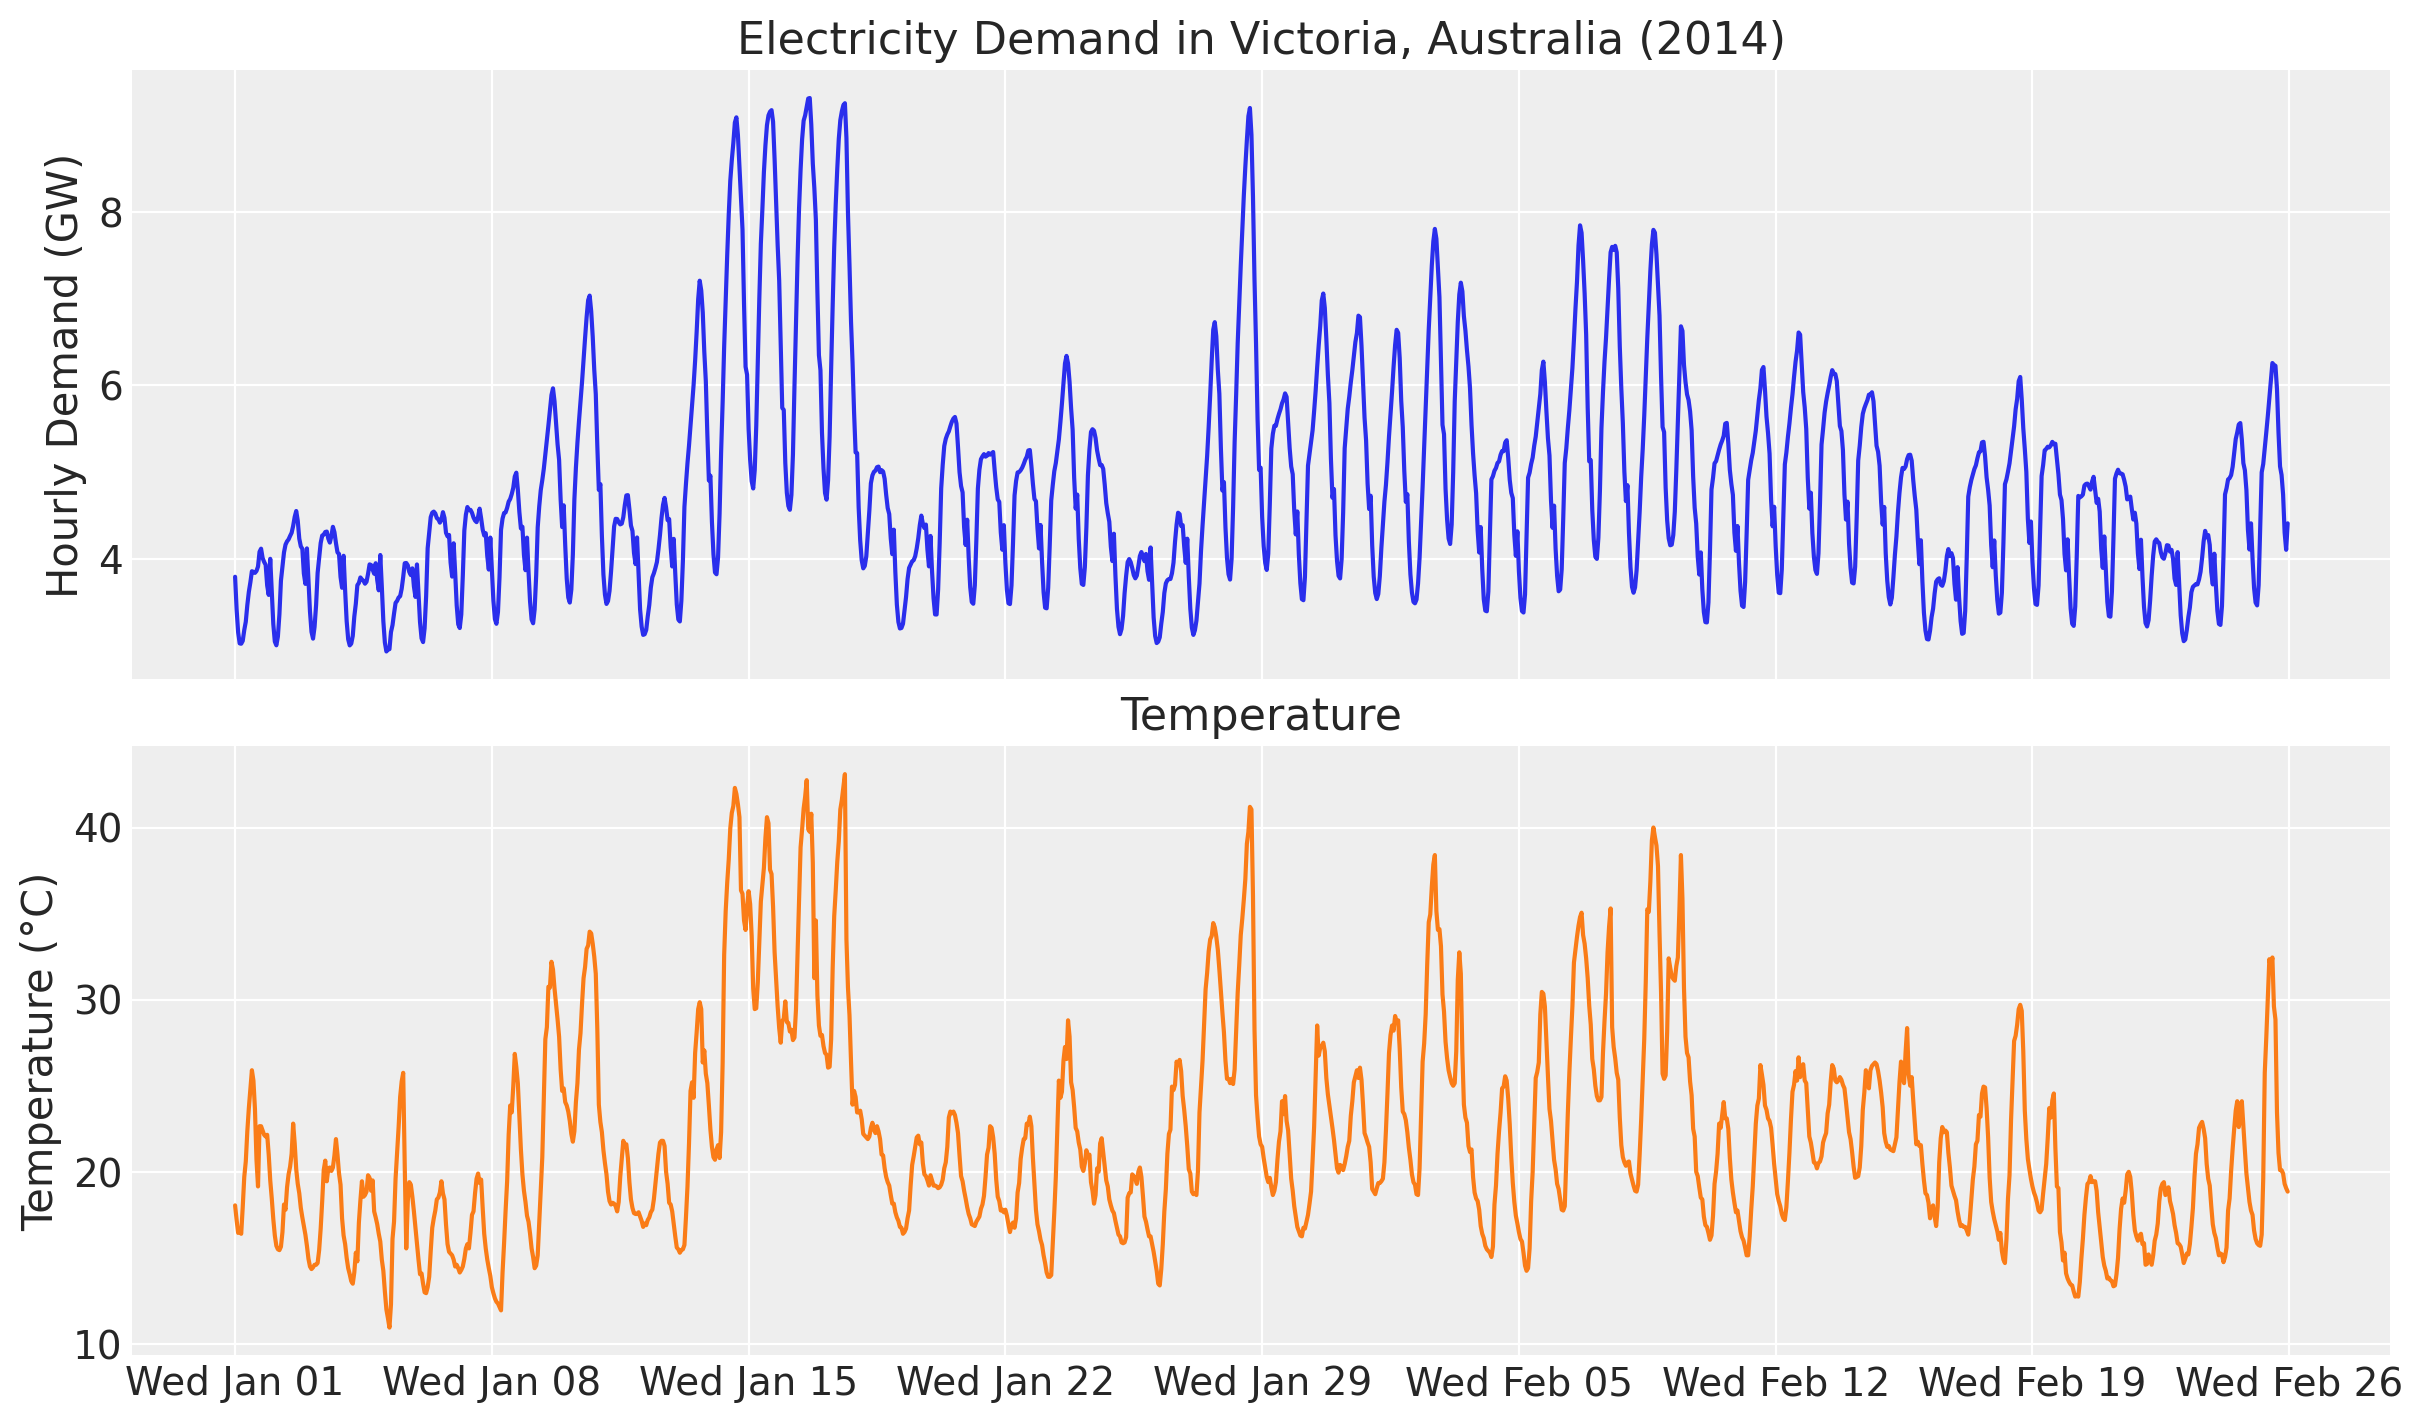

In [3]:
fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True, sharey=False, layout="constrained")
ax[0].plot(demand_dates, demand_values, c="C0")
ax[0].set(
    title="Electricity Demand in Victoria, Australia (2014)",
    ylabel="Hourly Demand (GW)",
)
ax[1].plot(demand_dates, temperature_values, c="C1")
ax[1].set(title="Temperature", ylabel="Temperature (°C)")
ax[1].xaxis.set_major_locator(demand_loc)
ax[1].xaxis.set_major_formatter(demand_fmt)

As in the baseline example, there is a clear positive correlation between temperature and demand, and the relationship is non-linear. The scatter plot below motivates the calibration: at the high end of the temperature range the air-conditioning effect dominates and the per-degree effect on demand settles around a stable value. This is exactly the regime where we will anchor the model with domain knowledge.

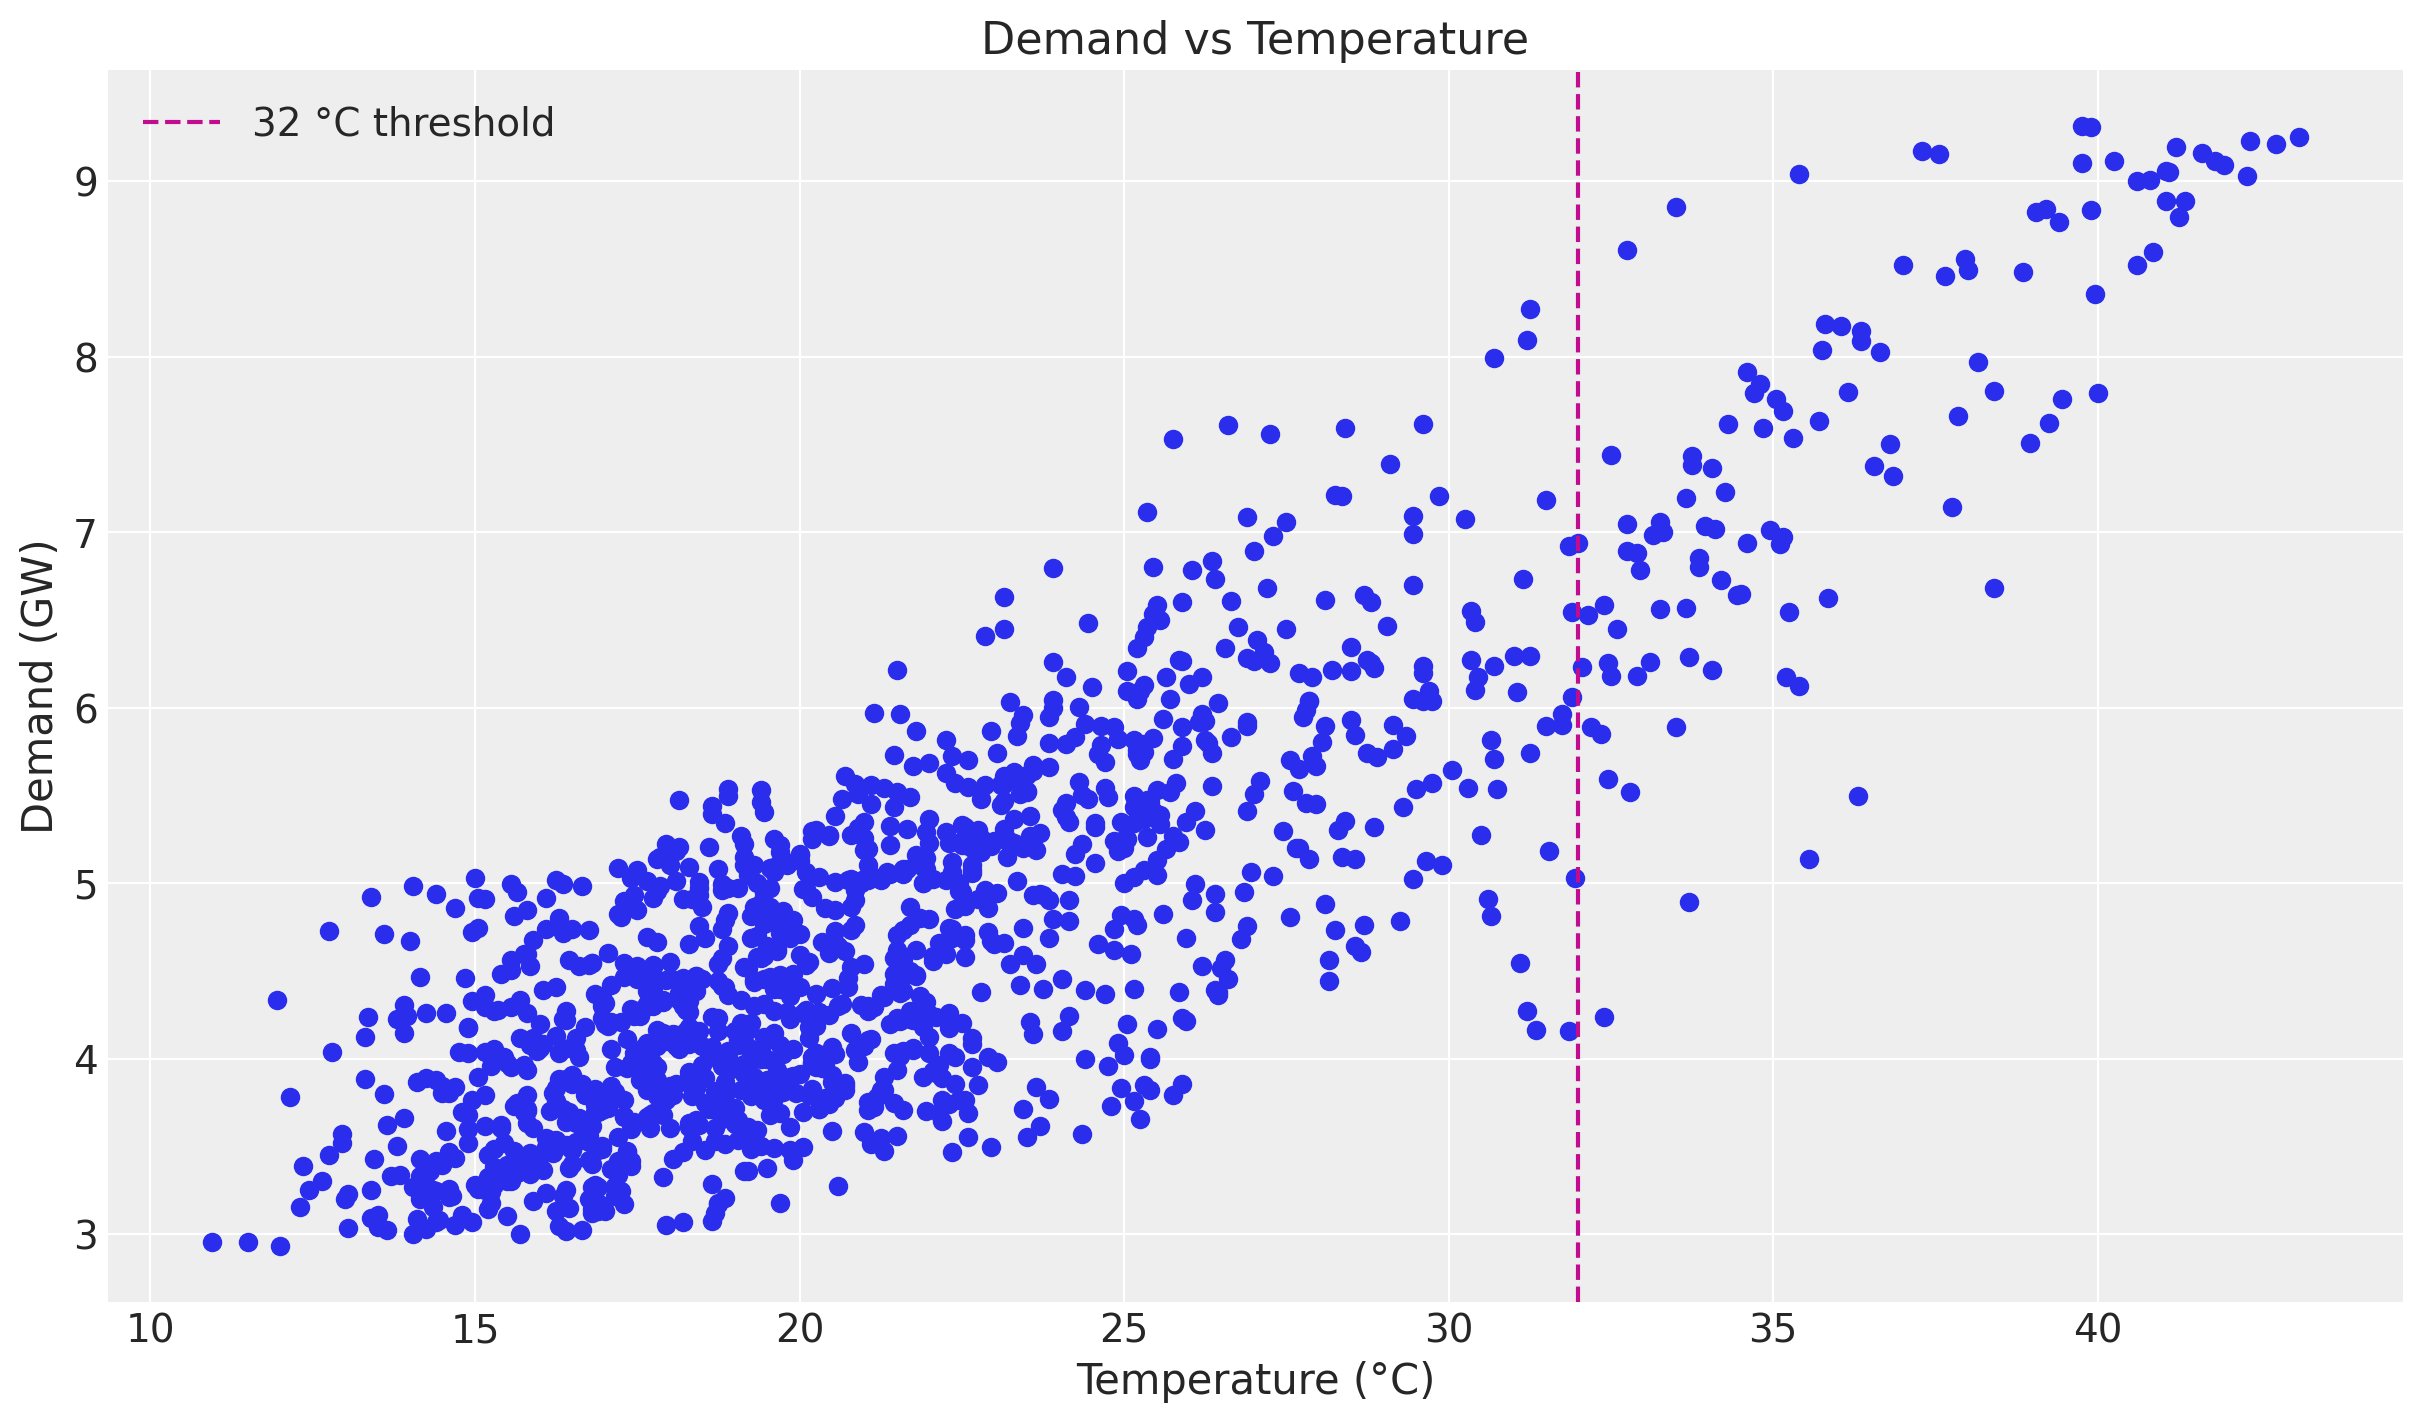

In [4]:
fig, ax = plt.subplots()
ax.scatter(temperature_values, demand_values)
ax.axvline(x=32.0, color="C3", linestyle="--", label="32 °C threshold")
ax.legend()
ax.set(title="Demand vs Temperature", xlabel="Temperature (°C)", ylabel="Demand (GW)");

## Training and test data

We split the data as in the original example, holding out the last two weeks. We build the exogenous inputs the model needs and pack them into a single `covariates` array with time at axis `-2`: the temperature and a `day_of_week` index. The forecast horizon is inferred later from `covariates` being longer than the training data.

In [5]:
num_forecast_steps = 24 * 7 * 2  # two weeks
t_train = duration - num_forecast_steps

data_train = demand[:t_train]
data_test = demand[t_train:]

dates_train = demand_dates[:t_train]
dates_test = demand_dates[t_train:]

day_of_week = np.array([d.weekday() for d in demand_dates.astype("datetime64[D]").astype(object)])

covariates = jnp.stack([temperature, jnp.asarray(day_of_week, dtype=jnp.float32)], axis=-1)
covariates_train = covariates[:t_train]

print("data_train shape:", data_train.shape)
print("data_test shape:", data_test.shape)
print("covariates shape:", covariates.shape)

data_train shape: (1008, 1)
data_test shape: (336, 1)
covariates shape: (1344, 2)


## Model specification

The model is the same `ForecastingModel` as in the baseline example:

- A linear-in-features model predicts demand from temperature and two seasonal effects, hour of day and day of week, both modeled with Zero-Sum Normal distributions.
- A Matérn 5/2 kernel models the temperature effect on demand through the Hilbert Space Gaussian Process (HSGP) approximation from NumPyro.
- The noise scale varies with the temperature, and a Student-t distribution models the residual error.

The only addition is the **calibration likelihood**. We assume that, from domain knowledge, the effect of temperature on demand for temperatures over `32 °C` is stable at around `0.13`. We encode this as an extra observation on the latent Gaussian Process coefficient `beta_temperature`.

### The calibration likelihood: index vs mask

In the standalone NumPyro model from the blog post, the calibration term is written by indexing the latent effect at the high-temperature timesteps:

```python
temperature_prior_idx = jnp.where(temperature_training_data > 32.0)[0]
numpyro.sample(
    "temperature_prior",
    dist.Normal(loc=0.13, scale=0.01),
    obs=beta_temperature[temperature_prior_idx],
)
```

In `numpyro_forecast` a single model handles both training and forecasting, so `covariates` (and therefore `beta_temperature`) change length between the two regimes and a fixed integer index does not translate cleanly. The idiomatic, jit-safe equivalent is a *masked* likelihood: we build a boolean mask from the temperature covariate and apply it with `numpyro.handlers.mask`.

These two formulations are mathematically identical at training time. `numpyro.handlers.mask` multiplies each element's `log_prob` by the `0/1` mask, so the calibration factor is the sum of `Normal(0.13, 0.01).log_prob(beta_temperature[t])` over exactly the timesteps where `temperature[t] > 32 °C`, the same terms the index version sums. The mask form has static shapes, works for both the in-sample fit and the forecast horizon, and during forecasting is harmless because `beta_temperature` is deterministic given the posterior and the forecast only reads the `forecast` site.

### GP prior parameters

As in the baseline example, we set the Gaussian Process amplitude and length-scale priors with `preliz` by assuming both come from an Inverse-Gamma distribution and specifying the support.

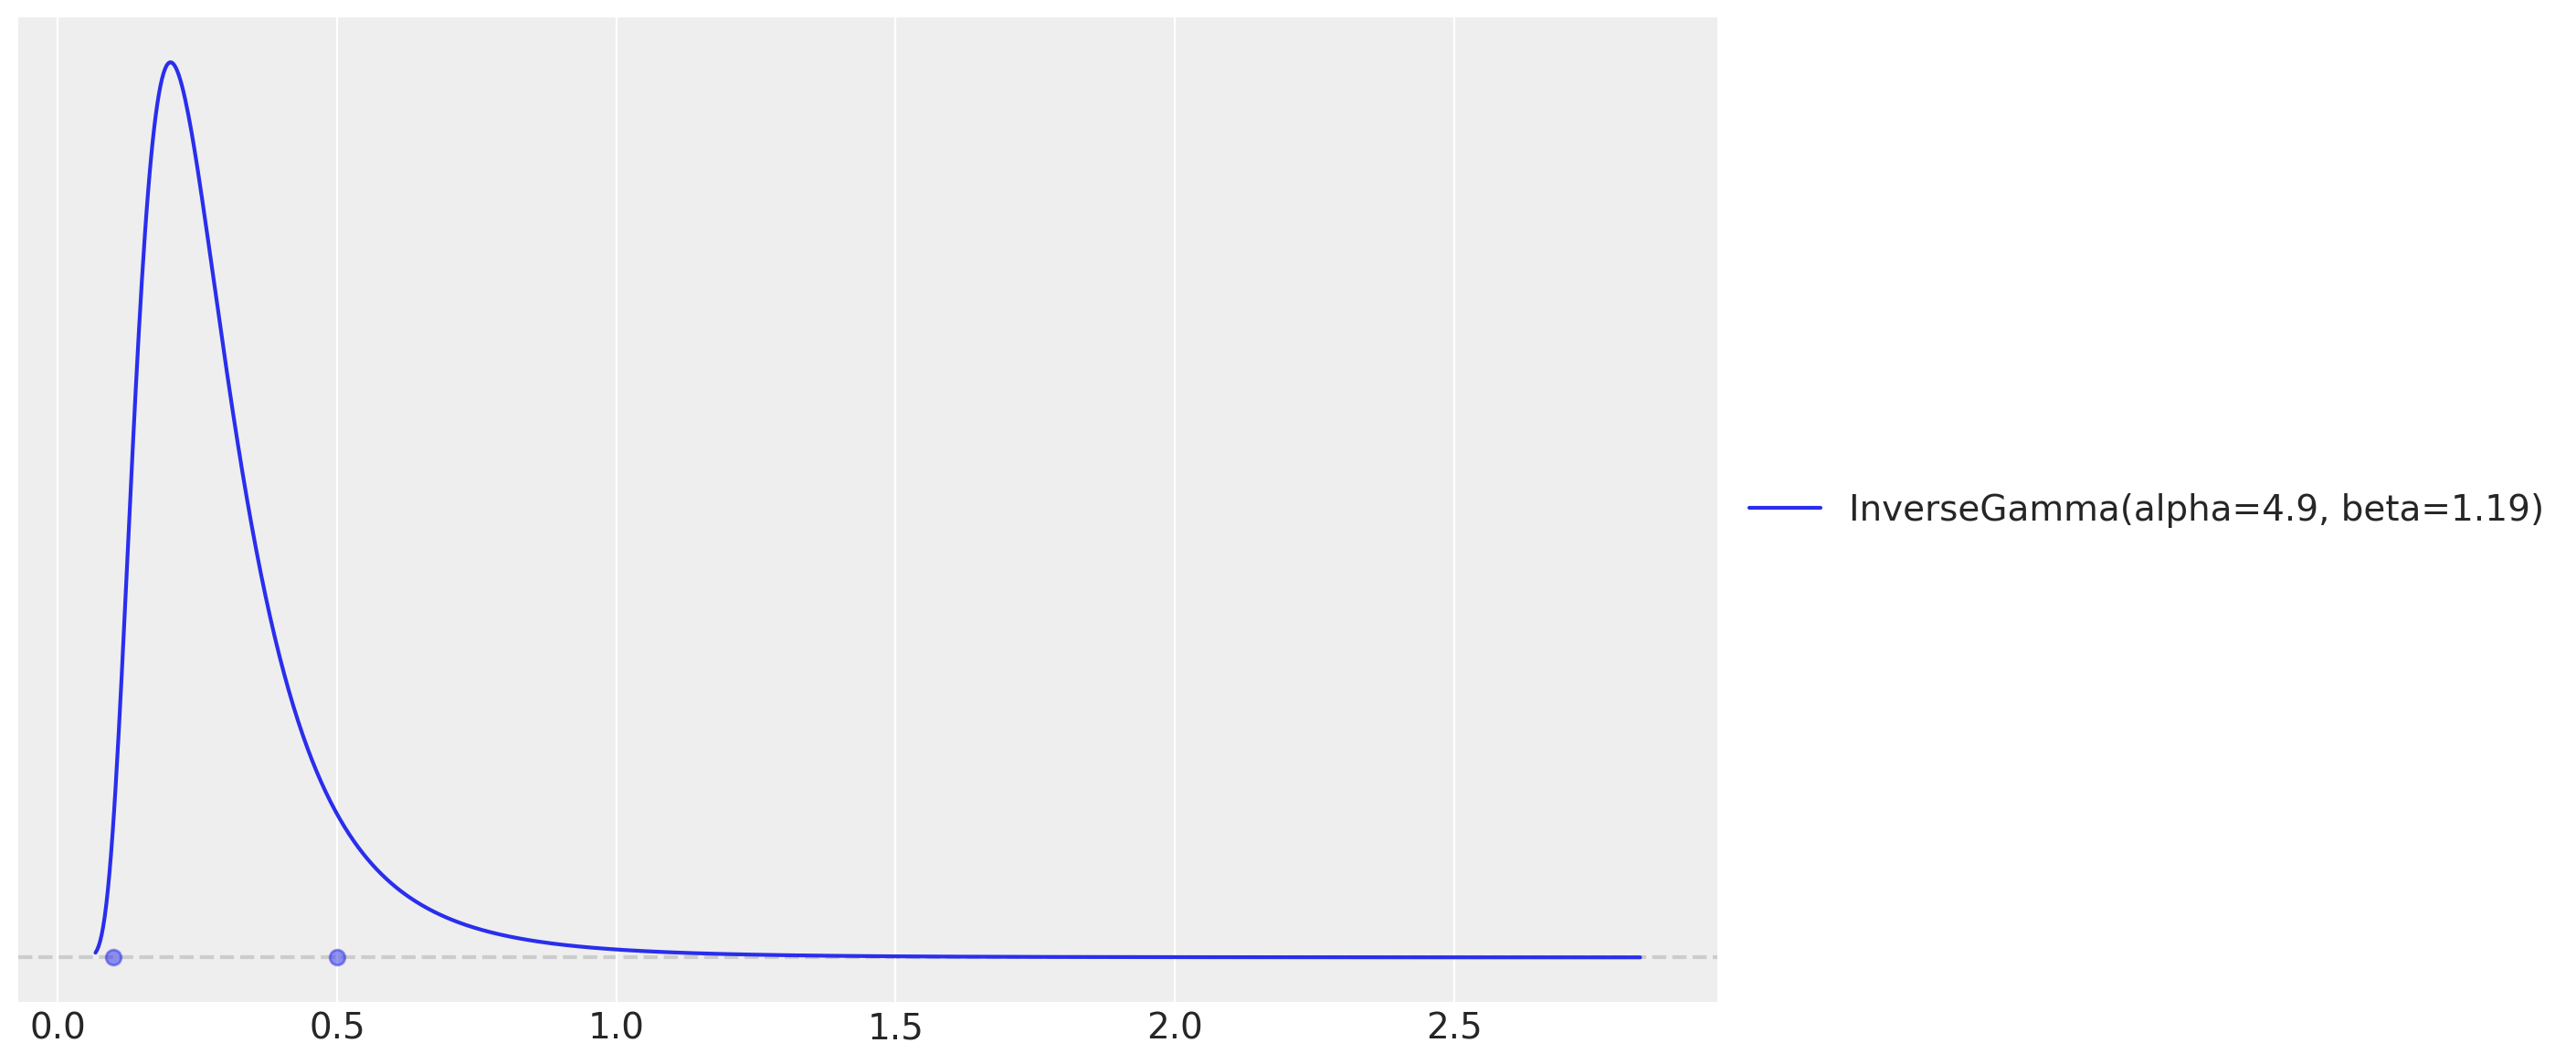

In [6]:
# For the amplitude, we set the values inspired on the range of the demand / temperature
# ratio.
_ = pz.maxent(pz.InverseGamma(), lower=0.1, upper=0.5)

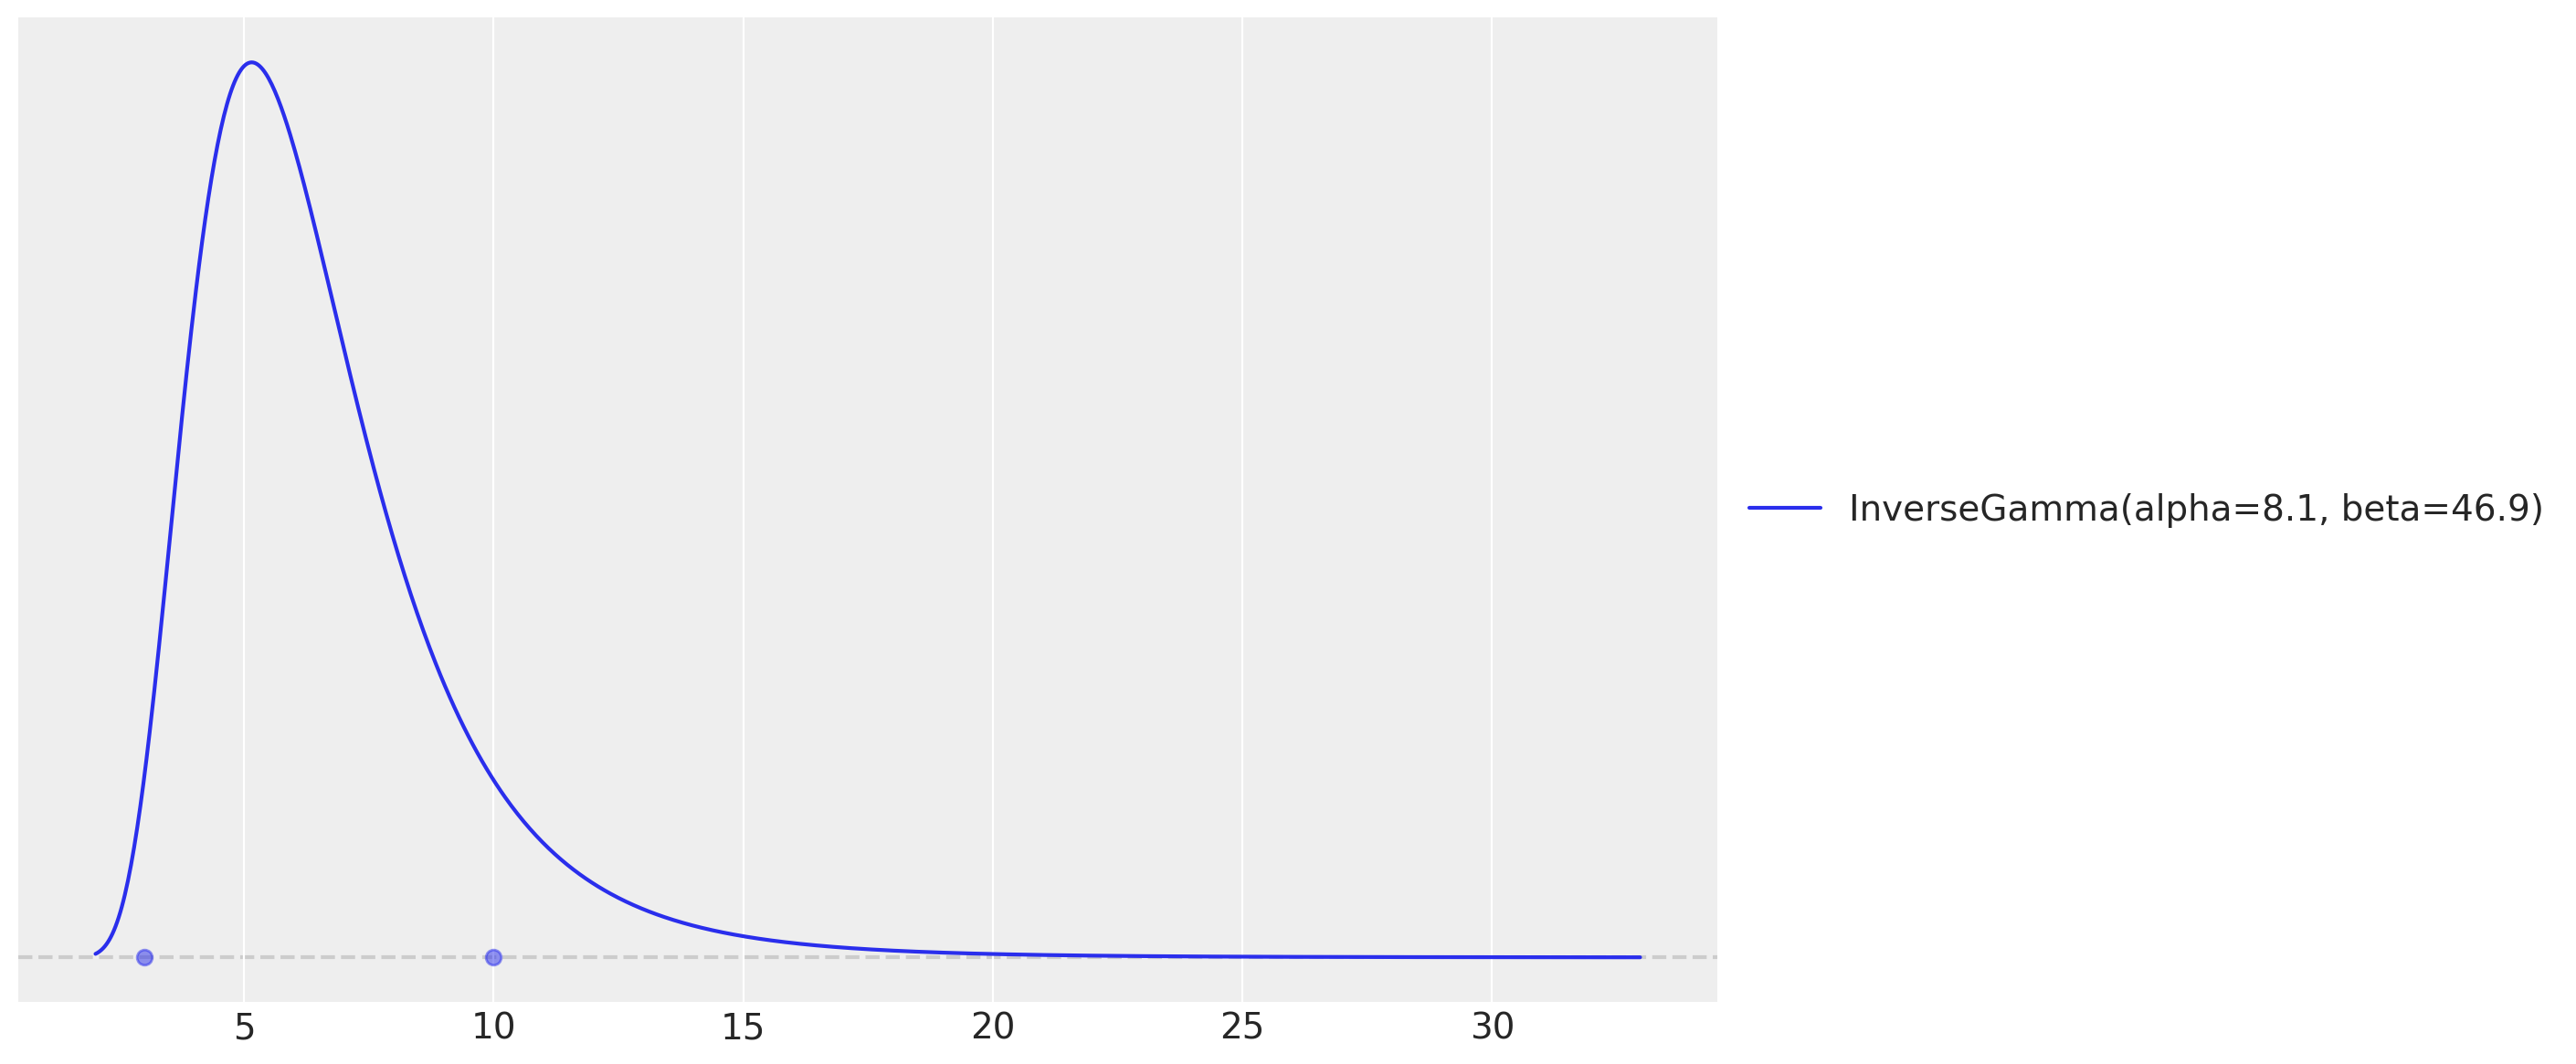

In [7]:
# As we want to use the GP to model the temperature effect, we need to set the length
# scale parameter. We expect these effects to be seen at the order of units or tens of
# units, so we expect the length scale to be between 3 and 10.
_ = pz.maxent(pz.InverseGamma(), lower=3, upper=10)

These two `maxent` calls return the Inverse-Gamma parameters we plug into the model below. The model is identical to the baseline, with the masked calibration likelihood added just after the `beta_temperature` deterministic site.

In [8]:
class CalibratedElectricityForecaster(ForecastingModel):
    """HSGP temperature effect with hour/day seasonality and a calibration likelihood.

    Same model as ``ElectricityForecaster`` in the baseline example, plus a
    masked Normal likelihood on the latent temperature effect that anchors it to
    a domain-knowledge value in the high-temperature regime.

    Parameters
    ----------
    ell
        Boundary factor for the HSGP approximation.
    m
        Number of basis functions for the HSGP approximation.
    temp_threshold
        Temperature (°C) above which the calibration likelihood is applied.
    prior_mean
        Domain-knowledge mean of the temperature effect above the threshold.
    prior_scale
        Scale (uncertainty) of the calibration likelihood.
    """

    def __init__(
        self,
        ell: float = 55.0,
        m: int = 25,
        temp_threshold: float = 32.0,
        prior_mean: float = 0.13,
        prior_scale: float = 0.01,
    ) -> None:
        super().__init__()
        self.ell = ell
        self.m = m
        self.temp_threshold = temp_threshold
        self.prior_mean = prior_mean
        self.prior_scale = prior_scale

    def model(self, zero_data: Array | None, covariates: Array) -> None:
        """Define the calibrated electricity-demand forecasting model."""
        duration = covariates.shape[-2]
        temperature = covariates[..., 0]
        day_of_week = covariates[..., 1].astype("int32")

        # Intercept.
        intercept = numpyro.sample("intercept", dist.Normal(loc=0.0, scale=2.0))

        # GP parameters (amplitude and length-scale priors are the preliz maxent fits).
        alpha = numpyro.sample("alpha", dist.InverseGamma(concentration=6.66, rate=1.57))
        length_scale = numpyro.sample(
            "length_scale", dist.InverseGamma(concentration=11.0, rate=62.2)
        )
        scale_factor = numpyro.sample("scale", dist.HalfNormal(scale=0.5))
        # Degrees of freedom for the Student-t likelihood.
        nu = numpyro.sample("nu", dist.Gamma(concentration=8.0, rate=3.0))

        # Non-linear temperature effect as a Matérn 5/2 HSGP. ``hsgp_matern`` is
        # annotated for float hyperparameters, so we cast the sampled scalars.
        beta_temperature = hsgp_matern(
            x=temperature,
            nu=5 / 2,
            alpha=cast("float", alpha),
            length=cast("float", length_scale),
            ell=self.ell,
            m=self.m,
        )
        numpyro.deterministic("beta_temperature", beta_temperature)

        # Calibration likelihood: anchor the latent temperature effect to the
        # domain-knowledge value where temperature exceeds the threshold. The mask
        # keeps only the high-temperature contributions, matching the blog's
        # ``beta_temperature[temperature_prior_idx]`` indexing.
        high_temp_mask = temperature > self.temp_threshold
        with numpyro.handlers.mask(mask=high_temp_mask):
            numpyro.sample(
                "temperature_prior",
                dist.Normal(loc=self.prior_mean, scale=self.prior_scale),
                obs=beta_temperature,
            )

        # Hour-of-day effect, tiled over the horizon with periodic_repeat.
        scale_hour_of_day = numpyro.sample("scale_hour_of_day", dist.HalfNormal(scale=0.5))
        hour_of_day_effect = numpyro.sample(
            "hour_of_day_effect",
            dist.ZeroSumNormal(scale=scale_hour_of_day, event_shape=(24,)),
        )
        hour_of_day_effect = periodic_repeat(hour_of_day_effect, duration, axis=-1)

        # Day-of-week effect, indexed by the calendar covariate.
        scale_day_of_week = numpyro.sample("scale_day_of_week", dist.HalfNormal(scale=0.5))
        day_of_week_effect = numpyro.sample(
            "day_of_week_effect",
            dist.ZeroSumNormal(scale=scale_day_of_week, event_shape=(7,)),
        )

        # Expected demand and a temperature-dependent Student-t noise scale.
        mu = (
            beta_temperature * temperature
            + intercept
            + hour_of_day_effect
            + jnp.take(day_of_week_effect, day_of_week)
        )
        scale = scale_factor * jnp.sqrt(temperature)

        self.predict(dist.StudentT(df=nu, loc=0.0, scale=scale[..., None]), mu[..., None])


model = CalibratedElectricityForecaster()

A `ForecastingModel` instance is itself the NumPyro model callable `(covariates, data=None)`, so we can render its structure directly. The rendered graph shows the new observed `temperature_prior` node next to the demand `obs` node.

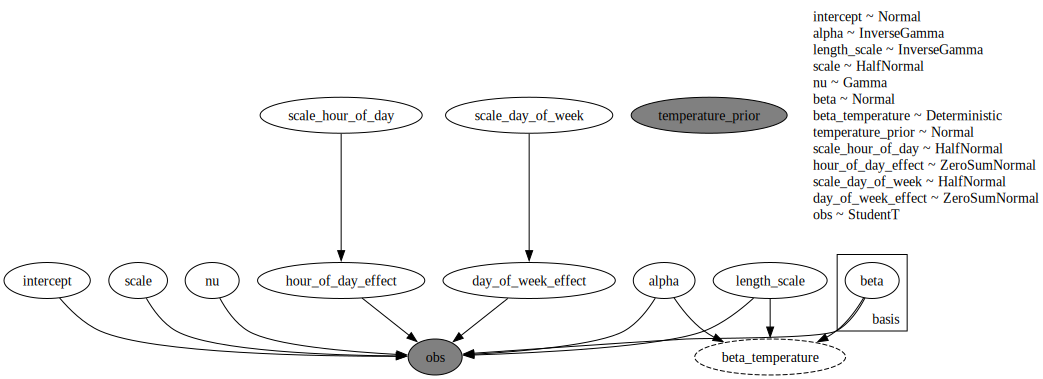

In [9]:
numpyro.render_model(
    model,
    model_args=(covariates_train, data_train),
    render_distributions=True,
    render_params=True,
)

## Prior predictive checks

Before we fit the model, let's visualize the prior predictive distribution. A `ForecastingModel` instance is a plain NumPyro model callable, so we can hand it to `Predictive` directly. We draw the bands with ArviZ's `plot_lm`, which computes the $50\%$ and $94\%$ HDI internally; since the time axis is a `datetime64` array we pass it as matplotlib date numbers (`mdates.date2num`) and restore the date formatter on the returned axis.

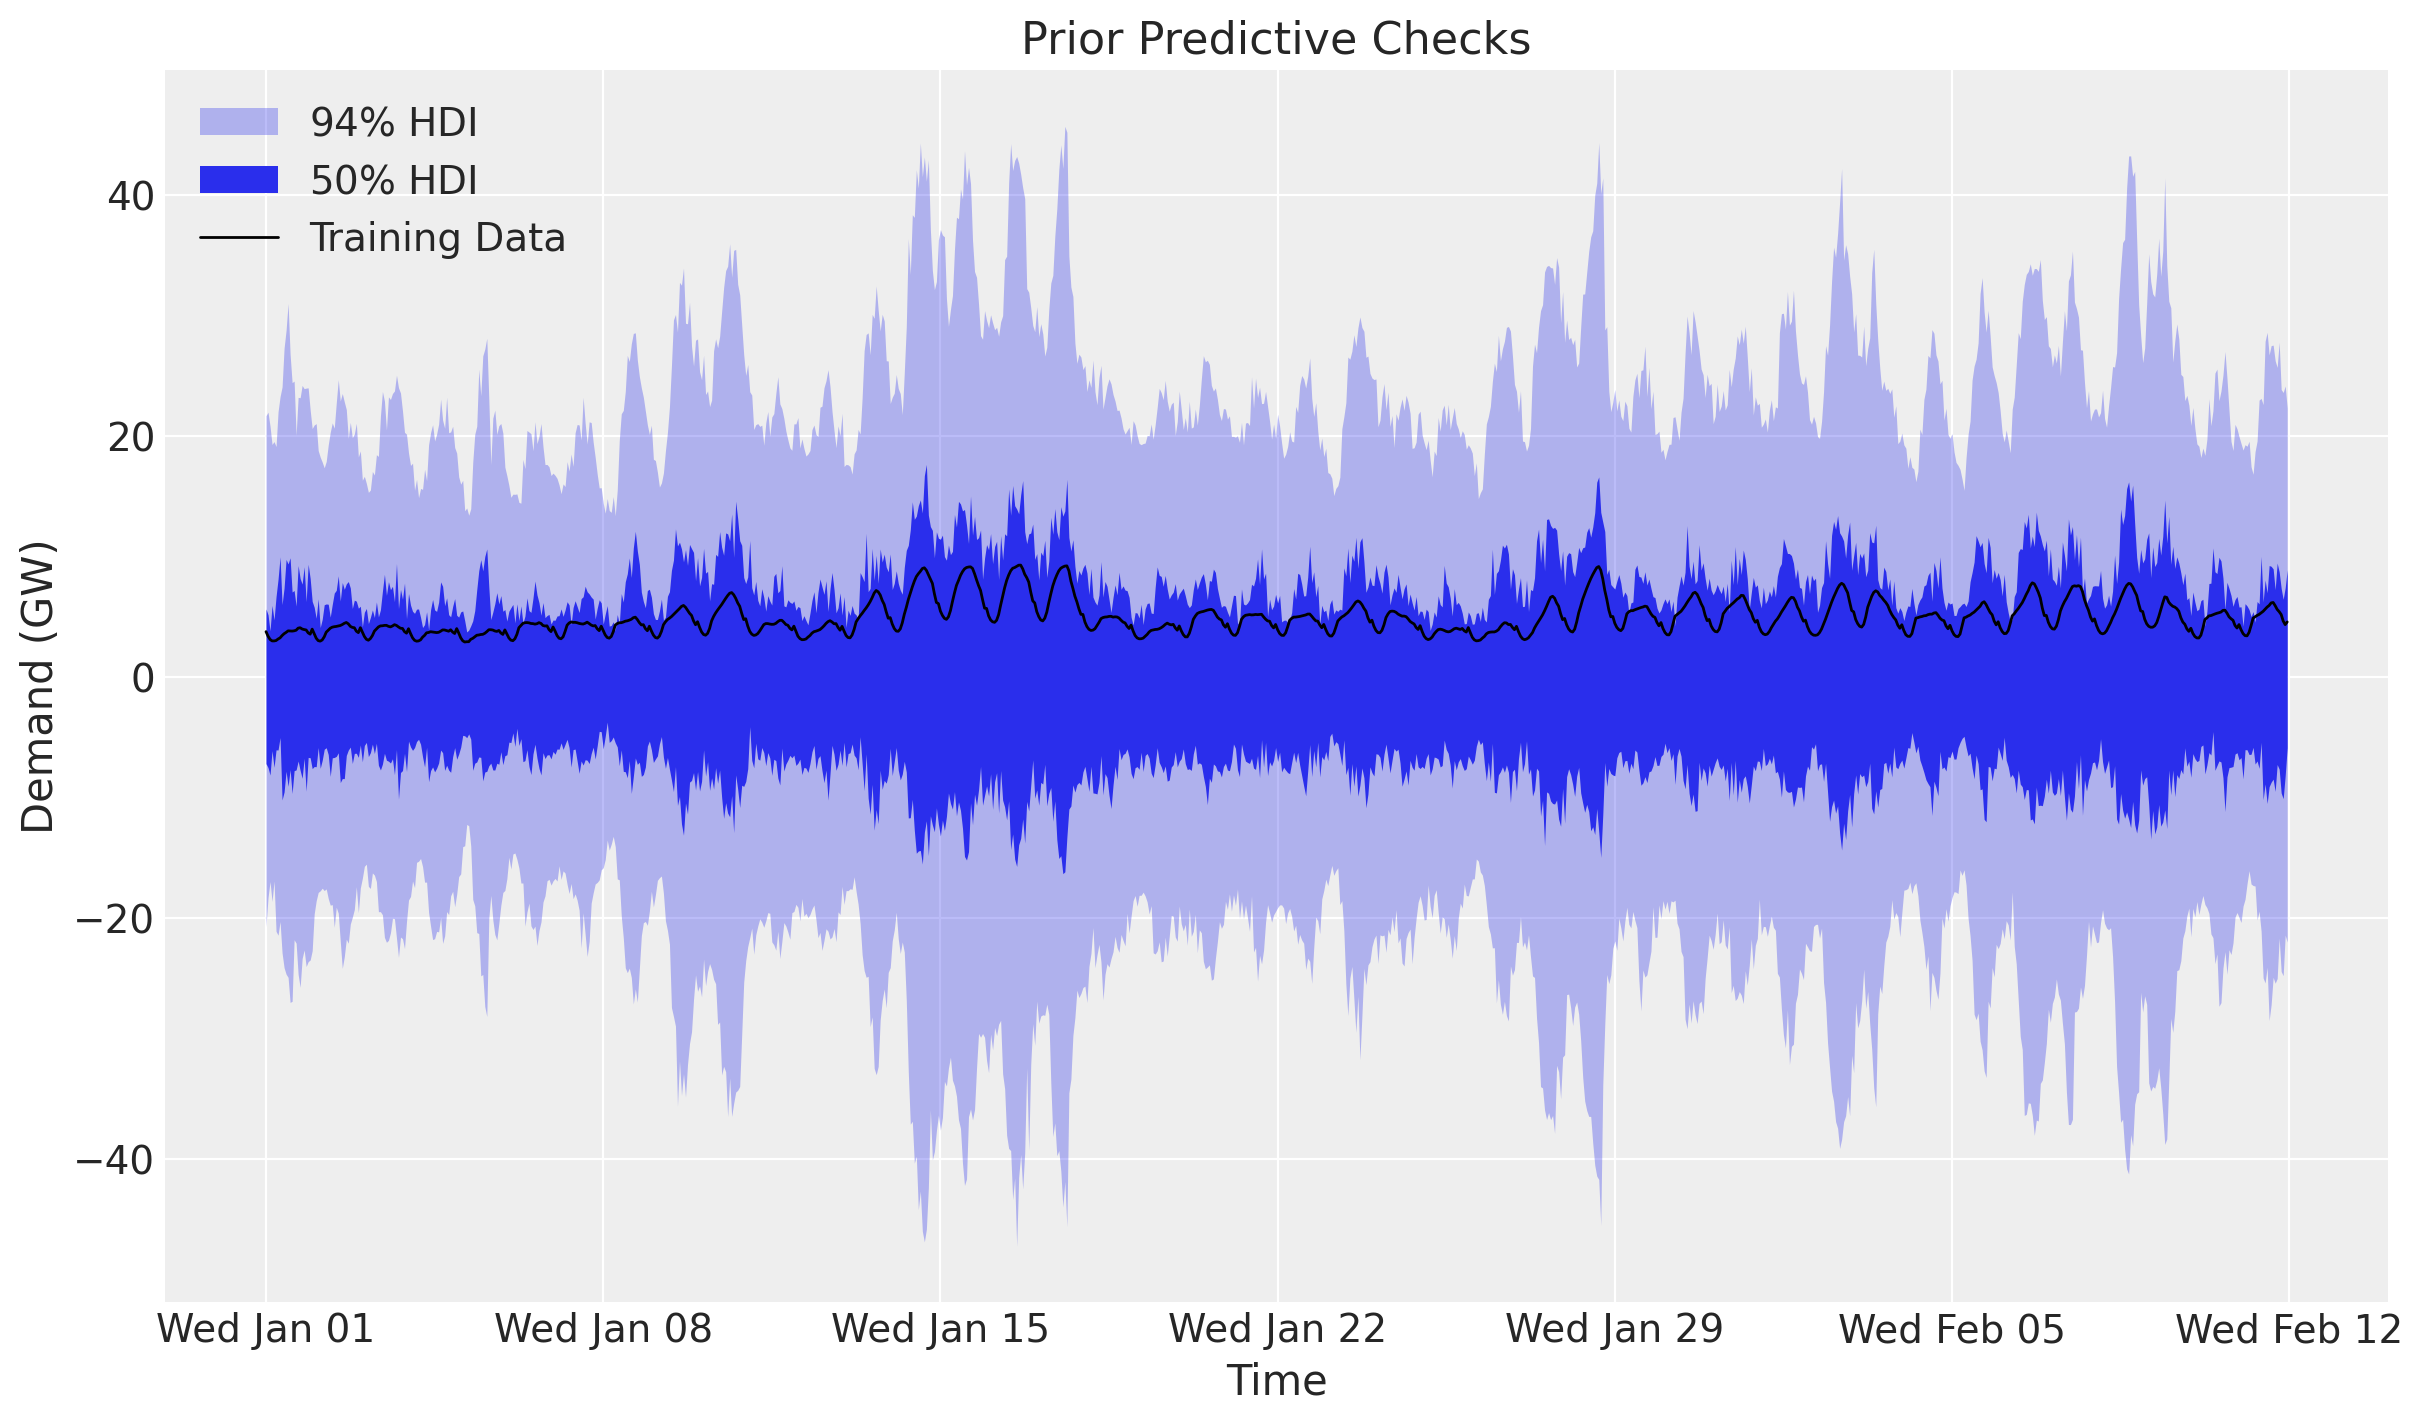

In [10]:
prior_predictive = Predictive(model, num_samples=2_000, return_sites=["obs"])
rng_key, rng_subkey = random.split(rng_key)
prior_obs = prior_predictive(rng_subkey, covariates_train)["obs"][..., 0]

xnum_train = mdates.date2num(dates_train)

idata_prior = az.from_dict(
    {
        "prior_predictive": {"obs": np.asarray(prior_obs)[None]},
        "observed_data": {"obs": np.asarray(data_train[:, 0])},
        "constant_data": {"date": xnum_train},
    },
    coords={"time": xnum_train},
    dims={"obs": ["time"], "date": ["time"]},
)
pc = az.plot_lm(
    idata_prior,
    y="obs",
    x="date",
    group="prior_predictive",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={"ci_band": {"color": "C0"}, "observed_scatter": False, "pe_line": False},
    figure_kwargs={"figsize": (12, 7)},
)
ax = pc.viz["figure"].item().axes[0]
bands = pc.viz["ci_band"]["date"]
band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
band_94.set_label(r"$94\%$ HDI")
band_50.set_label(r"$50\%$ HDI")
(train_line,) = ax.plot(
    xnum_train, np.asarray(data_train[:, 0]), c="black", lw=1, label="Training Data"
)
ax.xaxis.set_major_locator(demand_loc)
ax.xaxis.set_major_formatter(demand_fmt)
ax.legend(handles=[band_94, band_50, train_line])
ax.set(title="Prior Predictive Checks", ylabel="Demand (GW)", xlabel="Time");

## Inference with SVI

We fit the model with stochastic variational inference through the `Forecaster` class, which wraps the SVI fit and exposes the fitted `guide`, `params` and the ELBO `losses`. As in the baseline example, the posterior is multimodal: the multiplicative `beta_temperature * temperature` term trades off against the overall level, so a plain `AutoNormal` can settle on a monotonic temperature effect. We pass a custom guide initialized at a feasible point (`init_to_feasible`), which reliably recovers the heating-and-cooling (U-shaped) effect. We keep the same optimizer (`Adam(step_size=0.005)`) and number of steps (`50_000`) as the blog post.

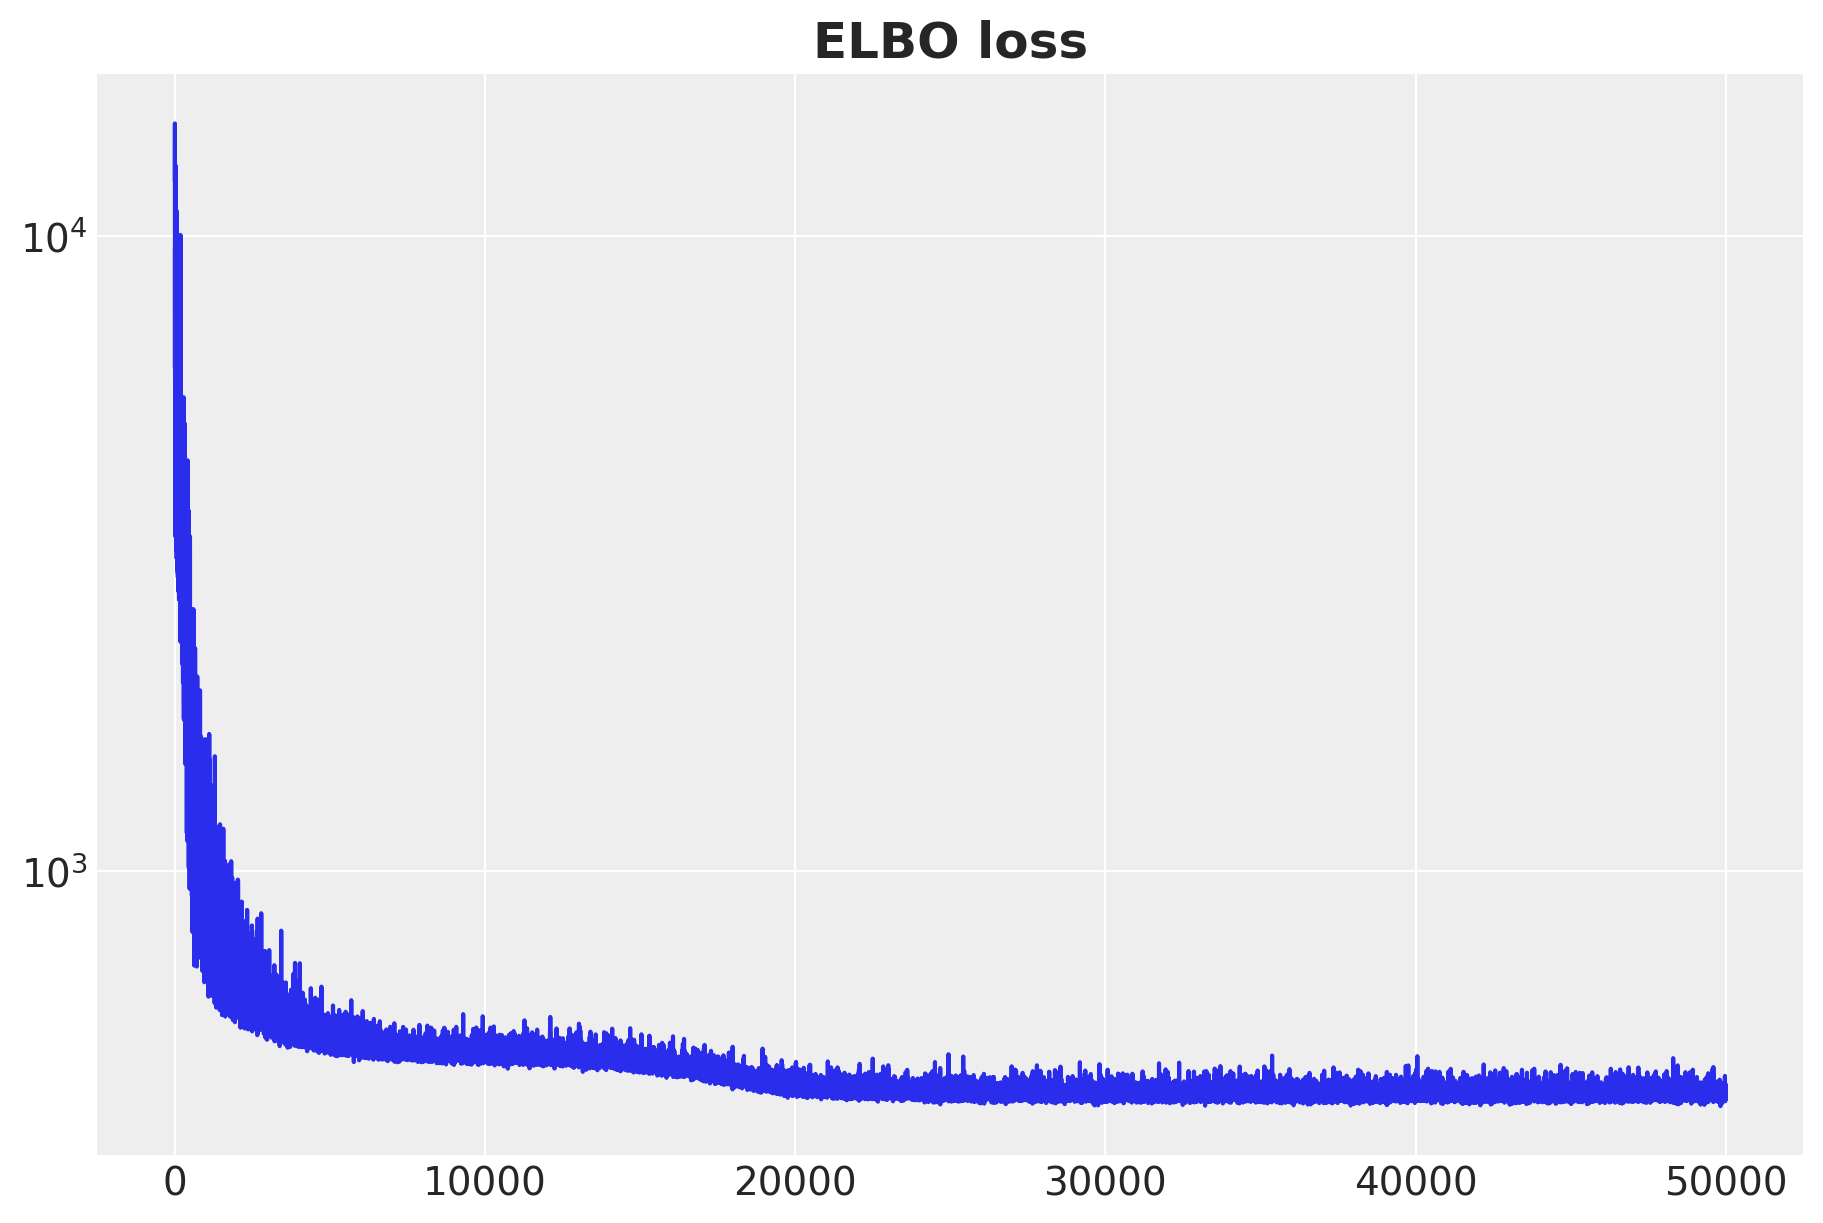

In [11]:
rng_key, rng_subkey = random.split(rng_key)
guide = AutoNormal(model, init_loc_fn=init_to_feasible)
forecaster = Forecaster(
    rng_subkey,
    model,
    data_train,
    covariates_train,
    guide=guide,
    optim=Adam(step_size=0.005),
    num_steps=50_000,
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(forecaster.losses)
ax.set_yscale("log")
ax.set_title("ELBO loss", fontsize=18, fontweight="bold");

The ELBO loss is decreasing as expected.

## Posterior predictive checks

We now generate in-sample posterior predictive samples (drawing posterior latents from the fitted guide and pushing them through the model) and forecast the held-out two weeks by calling the forecaster with the full-horizon covariates. We keep the deterministic `beta_temperature` site to inspect the calibrated temperature effect later.

In [12]:
num_posterior_samples = 5_000

rng_key, rng_subkey = random.split(rng_key)
posterior_samples = forecaster.guide.sample_posterior(
    rng_subkey, forecaster.params, sample_shape=(num_posterior_samples,)
)

rng_key, rng_subkey = random.split(rng_key)
train_posterior = Predictive(
    model, posterior_samples=posterior_samples, return_sites=["obs", "beta_temperature"]
)(rng_subkey, covariates_train)

rng_key, rng_subkey = random.split(rng_key)
forecast = forecaster(rng_subkey, data_train, covariates, num_samples=num_posterior_samples)

### Forecast evaluation

We score the train and test forecasts with `evaluate_forecast`, which reports several metrics at once: CRPS (the [Continuous Ranked Probability Score](https://en.wikipedia.org/wiki/Scoring_rule#Continuous_ranked_probability_score)), mean absolute error, root mean squared error, and the empirical coverage of the central 90% prediction interval. The scores should land close to the uncalibrated baseline: the calibration term refines the temperature effect in the high-temperature regime without hurting overall forecast accuracy.

In [13]:
train_metrics = evaluate_forecast(train_posterior["obs"], data_train)
test_metrics = evaluate_forecast(forecast, data_test)

metrics_table = pd.DataFrame({"train": train_metrics, "test": test_metrics})
metrics_table

,train,test
mae,0.389226,0.264660
rmse,0.520257,0.334297
crps,0.280324,0.192259
coverage,0.916667,0.994048


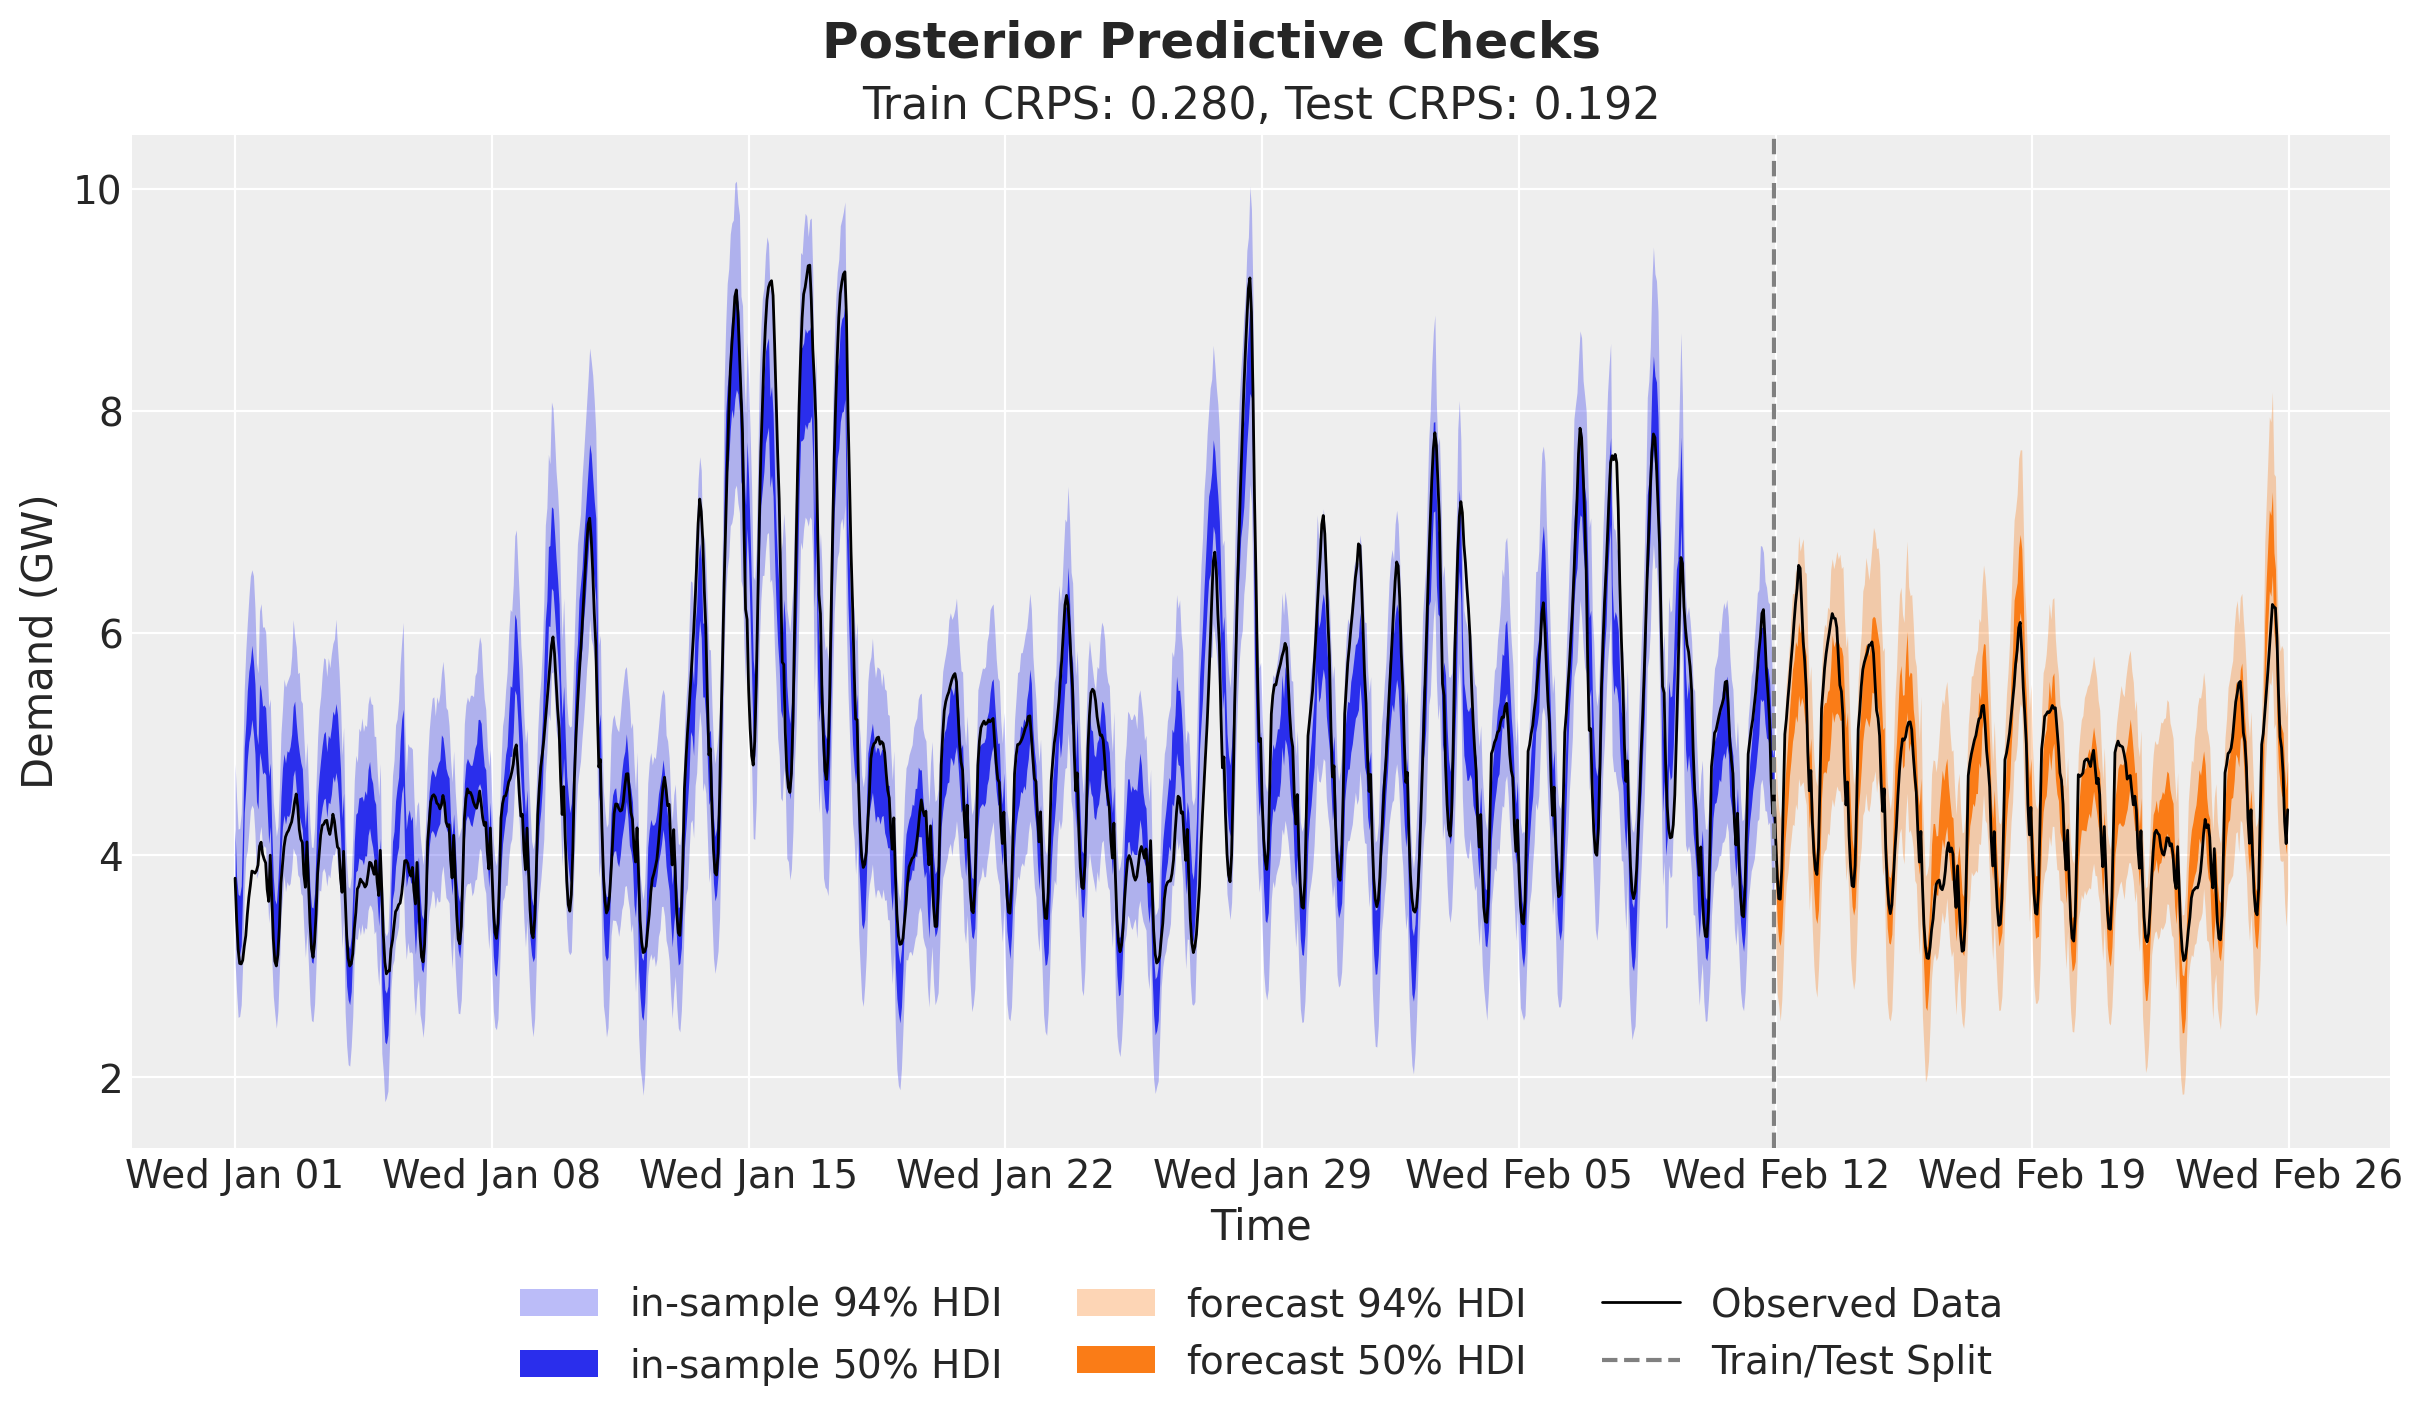

In [14]:
train_obs = train_posterior["obs"][..., 0]
forecast_obs = forecast[..., 0]

xnum_test = mdates.date2num(dates_test)

idata_train = az.from_dict(
    {
        "posterior_predictive": {"obs": np.asarray(train_obs)[None]},
        "observed_data": {"obs": np.asarray(data_train[:, 0])},
        "constant_data": {"date": xnum_train},
    },
    coords={"time": xnum_train},
    dims={"obs": ["time"], "date": ["time"]},
)
idata_test = az.from_dict(
    {
        "posterior_predictive": {"obs": np.asarray(forecast_obs)[None]},
        "observed_data": {"obs": np.asarray(data_test[:, 0])},
        "constant_data": {"date": xnum_test},
    },
    coords={"time": xnum_test},
    dims={"obs": ["time"], "date": ["time"]},
)

pc = az.plot_lm(
    idata_train,
    y="obs",
    x="date",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={"ci_band": {"color": "C0"}, "observed_scatter": False, "pe_line": False},
    figure_kwargs={"figsize": (12, 7)},
)
train_bands = pc.viz["ci_band"]["date"]
band_train_94 = train_bands.sel(prob=0.94).item()
band_train_50 = train_bands.sel(prob=0.5).item()
az.plot_lm(
    idata_test,
    y="obs",
    x="date",
    plot_collection=pc,
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
)
test_bands = pc.viz["ci_band"]["date"]
band_test_94 = test_bands.sel(prob=0.94).item()
band_test_50 = test_bands.sel(prob=0.5).item()
ax = pc.viz["figure"].item().axes[0]
band_train_94.set_label(r"in-sample $94\%$ HDI")
band_train_50.set_label(r"in-sample $50\%$ HDI")
band_test_94.set_label(r"forecast $94\%$ HDI")
band_test_50.set_label(r"forecast $50\%$ HDI")
obs_dates = mdates.date2num(np.concatenate([dates_train, dates_test]))
obs_values = np.concatenate([np.asarray(data_train[:, 0]), np.asarray(data_test[:, 0])])
(obs_line,) = ax.plot(obs_dates, obs_values, c="black", lw=1, label="Observed Data")
split_line = ax.axvline(x=xnum_train[-1], color="gray", linestyle="--", label="Train/Test Split")
ax.xaxis.set_major_locator(demand_loc)
ax.xaxis.set_major_formatter(demand_fmt)
ax.legend(
    handles=[band_train_94, band_train_50, band_test_94, band_test_50, obs_line, split_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(
    title=f"Train CRPS: {train_metrics['crps']:.3f}, Test CRPS: {test_metrics['crps']:.3f}",
    ylabel="Demand (GW)",
    xlabel="Time",
)
fig = pc.viz["figure"].item()
fig.suptitle("Posterior Predictive Checks", fontsize=18, fontweight="bold");

### Temperature effect on demand

This is where the calibration shows up. We plot the posterior distribution of the Gaussian Process component `beta_temperature` against temperature, sorting by temperature so the HDI band reads cleanly. The vertical line marks the `32 °C` threshold and the shaded band shows the calibration target of `0.13 ± 0.01` for temperatures above it.

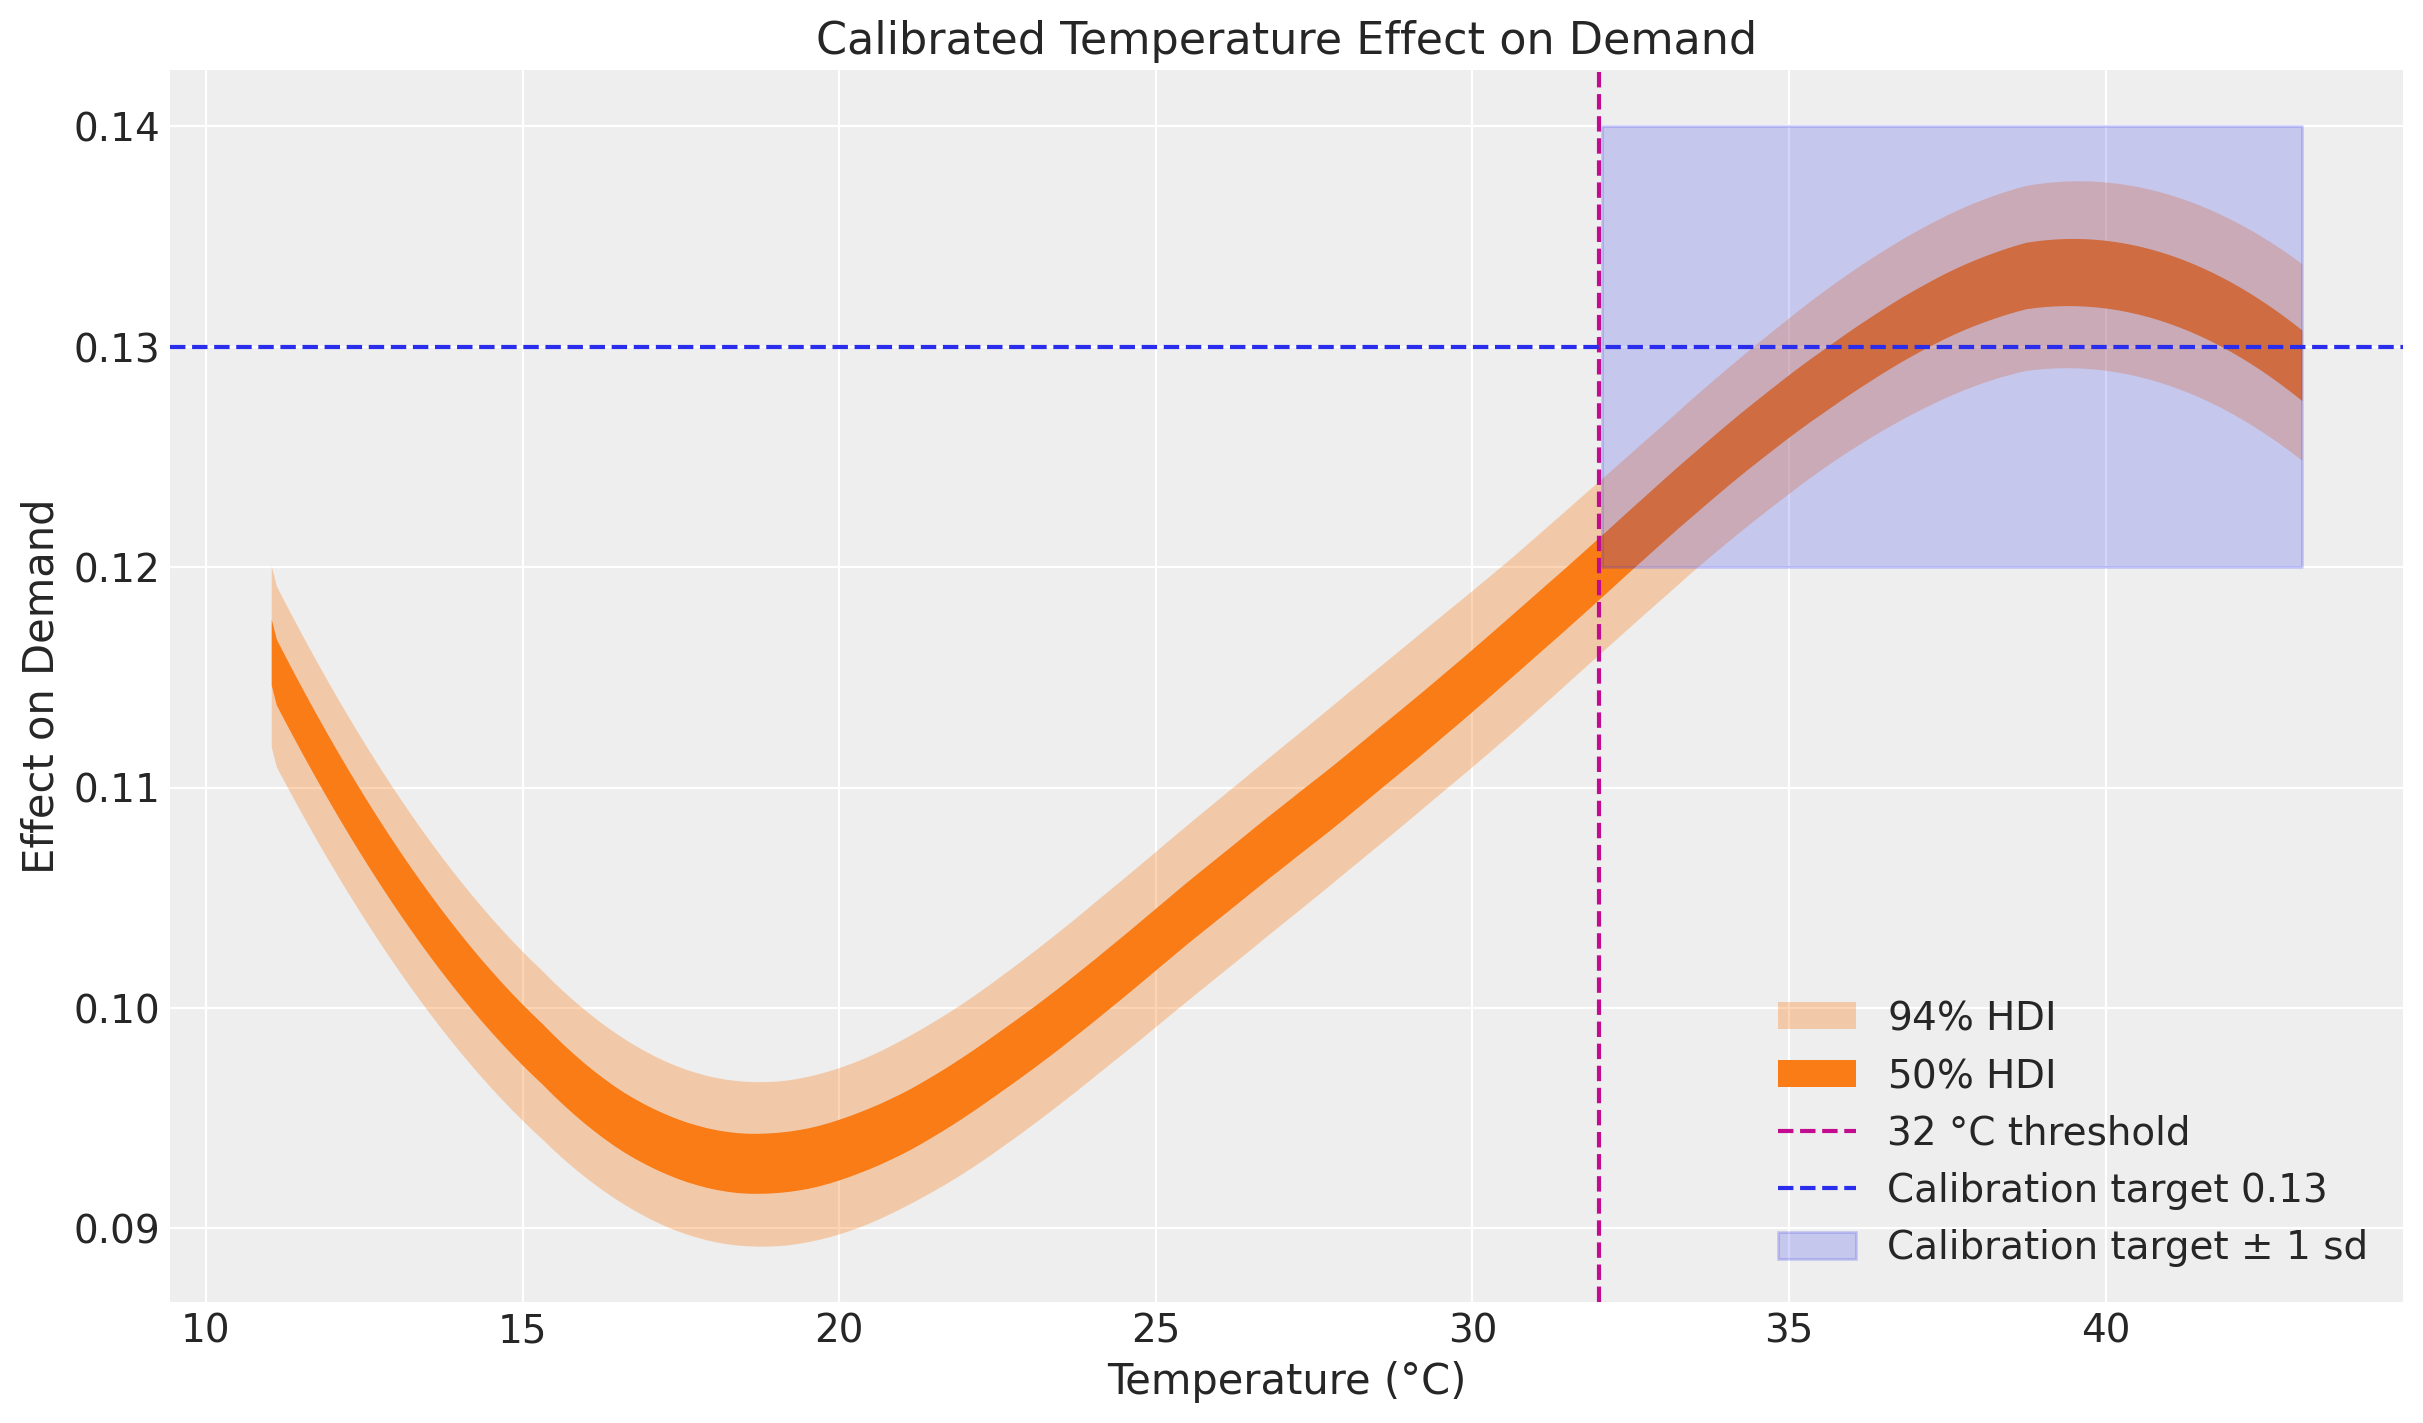

In [15]:
temperature_train = np.asarray(temperature[:t_train])
order = np.argsort(temperature_train)
beta_temperature = train_posterior["beta_temperature"]

prior_mean = model.prior_mean
prior_scale = model.prior_scale
threshold = model.temp_threshold

idata_beta = az.from_dict(
    {
        "posterior_predictive": {"obs": np.asarray(beta_temperature[:, order])[None]},
        "observed_data": {"obs": np.zeros_like(temperature_train[order])},
        "constant_data": {"temperature": temperature_train[order]},
    },
    dims={"obs": ["obs_dim"], "temperature": ["obs_dim"]},
)
pc = az.plot_lm(
    idata_beta,
    y="obs",
    x="temperature",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
    figure_kwargs={"figsize": (12, 7)},
)
ax = pc.viz["figure"].item().axes[0]
bands = pc.viz["ci_band"]["temperature"]
band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
band_94.set_label(r"$94\%$ HDI")
band_50.set_label(r"$50\%$ HDI")
threshold_line = ax.axvline(
    x=threshold, color="C3", linestyle="--", label=f"{threshold:.0f} °C threshold"
)
target_line = ax.axhline(
    y=prior_mean, color="C0", linestyle="--", label=f"Calibration target {prior_mean}"
)
high_temp = (temperature_train[order] > threshold).tolist()
target_band = ax.fill_between(
    temperature_train[order],
    prior_mean - prior_scale,
    prior_mean + prior_scale,
    where=high_temp,
    color="C0",
    alpha=0.2,
    label="Calibration target ± 1 sd",
)
ax.legend(handles=[band_94, band_50, threshold_line, target_line, target_band])
ax.set(
    title="Calibrated Temperature Effect on Demand",
    xlabel="Temperature (°C)",
    ylabel="Effect on Demand",
);

The overall shape of the curve resembles the one in the baseline uncalibrated [electricity demand example](electricity_forecast.ipynb): the temperature effect increases at both extremes of the common temperature range, reflecting the heating and cooling effects noted by Hyndman and Athanasopoulos. The difference is at the high end: the calibration likelihood pulls the estimate for temperatures over `32 °C` toward the expected value of `0.13`, with noticeably tighter credible bands than in the uncalibrated model.

This opens up nice opportunities to calibrate forecasting models with domain knowledge, possibly extracted from experimental or observational data. The mechanism is general: any latent quantity in a `ForecastingModel` can be anchored with an extra observed `numpyro.sample` site, optionally masked to the region where the domain knowledge applies.